In [1]:
import numpy as np
import sys
import os
import VBMicrolensing
import emcee
import h5py
import math
import matplotlib.pyplot as plt
import concurrent.futures
import corner
from tqdm import tqdm
VBM = VBMicrolensing.VBMicrolensing()
JD0 = 2450000
from matplotlib.lines import Line2D
sys.path.append("/moao38_7/nunota/genulens/genprior/gentool/")
from gapmoe import gapmoe
gapmoe_model = gapmoe(rhos_path="/moao38_7/nunota/genulens/genprior/test_data/riron_ns.dat",
                      mass_path="/moao38_7/nunota/binfit/work/MB23162/tool/check_Mhist.dat",
                      mu_path="/moao38_7/nunota/genulens/genprior/test_data/murel_hist.dat")
gapmoe_model.set_data(fREM_range=[0])

import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap

In [2]:
kappa = 8.144; #mas /MO
G = 2.959122082855911e-4 
thS=0.01

@jit
def calc_physical_params_jax(x):

    tE, rho, s, piEN, piEE, gamma1, gamma2, gamma3 = x
    piE = jnp.sqrt(piEE**2 + piEN**2)
    
    thE = thS / rho
    ML = thE / kappa / piE
    murel = thE / tE * 365.25
    murel_E = murel * piEE / piE
    murel_N = murel * piEN / piE

    gamma_sq = gamma1**2 + gamma2**2 + gamma3**2
    gamma_parallel = jnp.sqrt(gamma1**2 + gamma3**2)
    gamma_ratio = gamma_parallel / gamma3
    orbital_scale = jnp.cbrt((s**3) * gamma_sq * gamma_ratio / (ML * G))
    gamma_abs = jnp.sqrt(gamma_sq)
    Ds = 1 / ((orbital_scale - piE) * thE)

    pi_rel = thE * piE
    pi_S = 1 / Ds
    pi_L = pi_rel + pi_S
    DL = 1 / pi_L

    RE = DL * thE
    orbital_radi = RE * s * gamma_parallel / gamma3

    cosi = gamma3 * gamma2 / (gamma_parallel * gamma_abs)
    tanphi = - gamma1 * gamma_abs / (gamma3 * gamma_parallel)

    return jnp.array([murel_E, murel_N, ML, DL, Ds, orbital_radi, cosi, tanphi])

In [16]:
# 上限・下限設定：各パラメータの [min, max]
param_bounds = {
    "tE":    (1.0, 2000.0),        
    "rho":  (1e-4, 1),        
    "s":    (0.1, 5.0),           
    "piEN": (-1, 1),          
    "piEE": (-1, 1),          
    "gamma1": (-1.0, 1.0),        
    "gamma2": (-1.0, 1.0), 
    "gamma3": (0.001, 10.0),
}

param_bounds = {
    "tE":    (1.0, 100),  
    "rho":  (1e-10, 1e-2),    
    "s":    (0.1,1.5),
    "piEN": (-0.3, 0.3),          
    "piEE": (-0.3, 0.3),          
    "gamma1": (-0.03, 0.04),        
    "gamma2": (-0.04, 0.04), 
    "gamma3": (-0.05, 0.05),
}

param_bounds = {
    "tE":    (1.0, 1000),     
    "rho":  (1e-10, 5e-1), 
    "s":    (0.1,5),  
    "piEN": (-3, 3),
    "piEE": (-3, 3),
    "gamma1": (-0.02, 0.02),        
    "gamma2": (-0.02, 0.02), 
    "gamma3": (-0.02, 0.02),
}

# param_bounds = {
#     "tE":    (1.0, 1000),        
#     "rho":  (0, 1),        
#     "s":    (0.1,3),           
#     "piEN": (-3, 3),          
#     "piEE": (-3, 3),          
#     "gamma1": (-0.02, 0.02),        
#     "gamma2": (-0.02, 0.02), 
#     "gamma3": (-0.02, 0.02),
# }

# param_bounds = {
#     "tE":    (0.1,100),        
#     "rho":  (0, 1e-1), 
#     "s":    (0.5,1.5),           
#     "piEN": (-5, 5),          
#     "piEE": (-5, 5),            
#     "gamma1": (-.01, .01),        
#     "gamma2": (-.01, .01), 
#     "gamma3": (-.01, .01),
# }

# サンプル数
N = 100000

# 一様分布からサンプリング
rng = np.random.default_rng(seed=42)
samples = np.stack([
    rng.uniform(low, high, N)
    for (low, high) in param_bounds.values()
], axis=-1)

batched_calc = vmap(calc_physical_params_jax)
physical_params = batched_calc(jnp.array(samples))  

In [17]:

data = np.array(physical_params)

# fig = corner.corner(
#     data[:,:2][np.where((data[:,0]**2 + data[:,1]**2 < 50**2))],
#     labels=param_names,
#     show_titles=True,
#     title_fmt=".2e",
#     title_kwargs={"fontsize": 12},
#     label_kwargs={"fontsize": 14},
#     bins=40,
#     max_n_ticks=4,
#     smooth=1.0,
#     color="C0",
#     hist_kwargs={"density": True, "alpha": 0.8}
# )

# plt.show()

In [18]:
# param_names = ["mu_E", "mu_N", "ML", "DL", "Ds", "orbital_r", "cos(i)", "tan(phi)"]

# data = np.array(physical_params)

# # corner プロット実行
# fig = corner.corner(
#     data,
#     labels=param_names,
#     show_titles=True,
#     title_fmt=".2e",
#     title_kwargs={"fontsize": 12},
#     label_kwargs={"fontsize": 14},
#     bins=40,
#     max_n_ticks=4,
#     smooth=1.0,
#     color="C0",
#     hist_kwargs={"density": True, "alpha": 0.8}
# )

# plt.show()

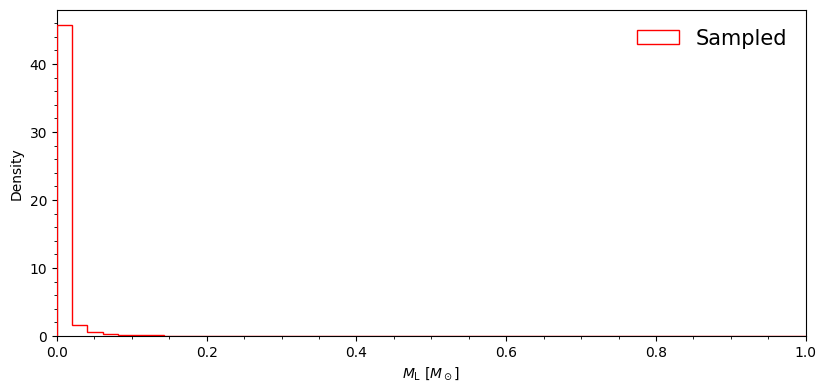

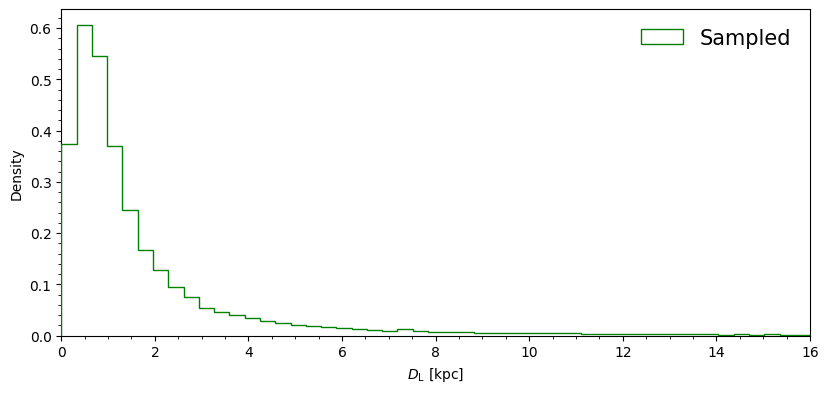

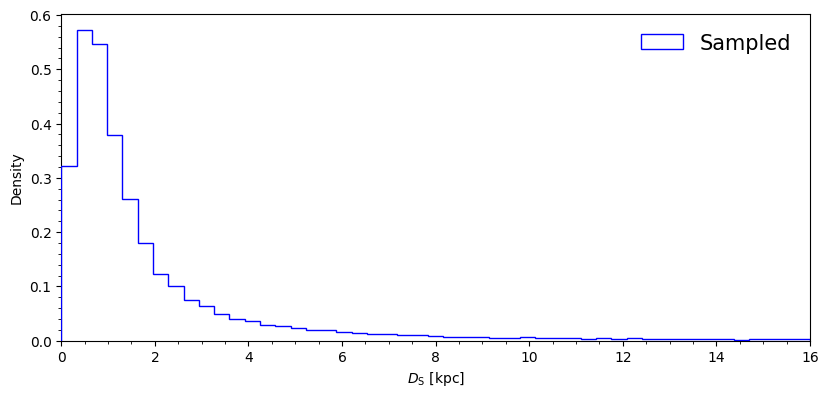

In [19]:
ML_array = physical_params[:, 2]
DL_array = physical_params[:, 3]
Ds_array = physical_params[:, 4]
rad_array = physical_params[:, 5]

plt.figure(figsize=(9.6, 4.8))
plt.hist(ML_array, bins=np.linspace(0, 1, 50),
         density=True,
         histtype="step", color="red", lw=4, label="Sampled", zorder=10)

plt.xlabel(r"$M_{\rm L}\ [M_\odot]$")
plt.ylabel("Density")
plt.xlim(0, 1)
plt.ylim(0, None)
plt.legend(fontsize=15, frameon=False, loc="upper right")
plt.minorticks_on()
plt.subplots_adjust(bottom=0.2, left=0.12)
plt.show()

plt.figure(figsize=(9.6, 4.8))
plt.hist(DL_array, bins=np.linspace(0, 16, 50),
         density=True,
         histtype="step", color="green", lw=4, label="Sampled", zorder=10)

plt.xlabel(r"$D_{\rm L}\ [{\rm kpc}]$")
plt.ylabel("Density")
plt.xlim(0, 16)
plt.ylim(0, None)
plt.legend(fontsize=15, frameon=False, loc="upper right")
plt.minorticks_on()
plt.subplots_adjust(bottom=0.2, left=0.12)
plt.show()

plt.figure(figsize=(9.6, 4.8))
plt.hist(Ds_array, bins=np.linspace(0, 16, 50),
         density=True,
         histtype="step", color="blue", lw=4, label="Sampled", zorder=10)

plt.xlabel(r"$D_{\rm S}\ [{\rm kpc}]$")
plt.ylabel("Density")
plt.xlim(0, 16)
plt.ylim(0, None)
plt.legend(fontsize=15, frameon=False, loc="upper right")
plt.minorticks_on()
plt.subplots_adjust(bottom=0.2, left=0.12)
plt.show()

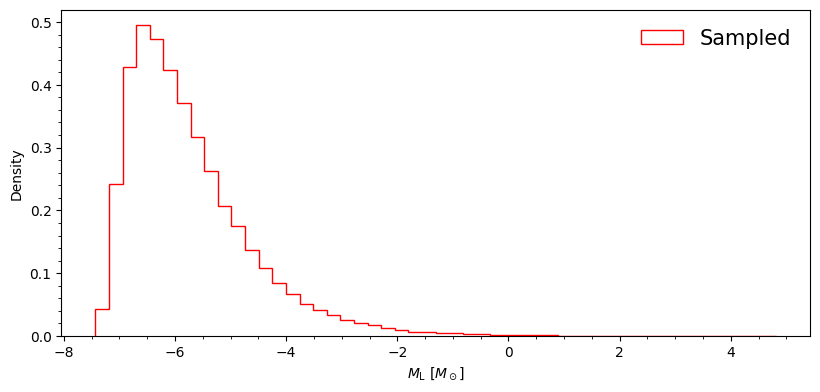

/tmp/ipykernel_145944/1380288862.py:21: RuntimeWarning: invalid value encountered in log
  plt.hist(np.log(DL_array), bins=50,


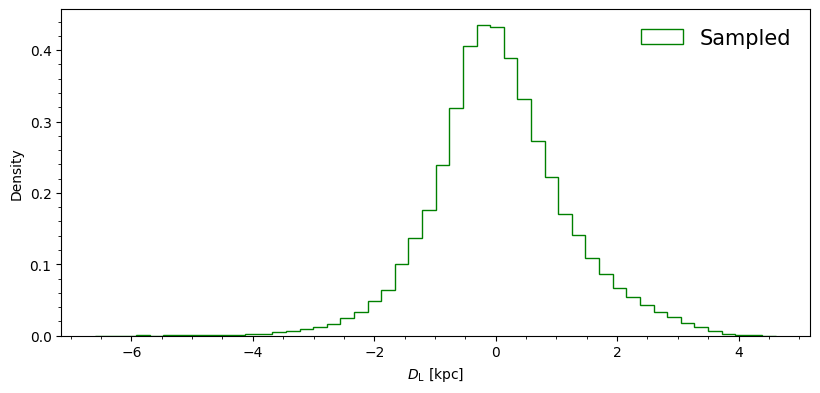

/tmp/ipykernel_145944/1380288862.py:35: RuntimeWarning: invalid value encountered in log
  plt.hist(np.log(Ds_array), bins=50,


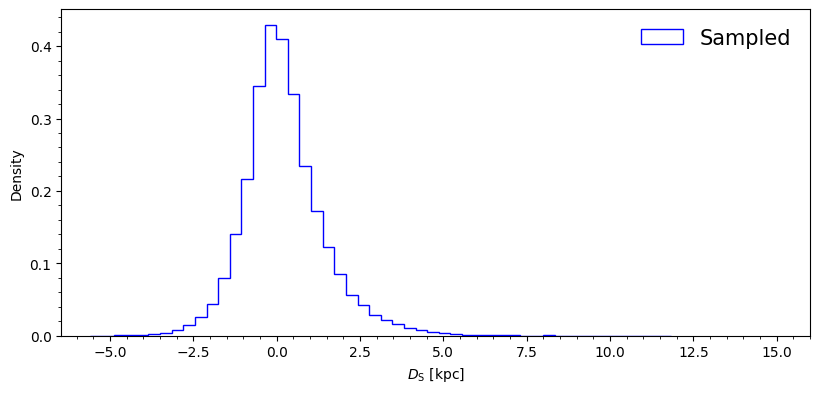

In [20]:
ML_array = physical_params[:, 2]
DL_array = physical_params[:, 3]
Ds_array = physical_params[:, 4]
rad_array = physical_params[:, 5]

plt.figure(figsize=(9.6, 4.8))
plt.hist(np.log(ML_array), bins=50,
         density=True,
         histtype="step", color="red", lw=4, label="Sampled", zorder=10)

plt.xlabel(r"$M_{\rm L}\ [M_\odot]$")
plt.ylabel("Density")
# plt.xlim(0, 1)
plt.ylim(0, None)
plt.legend(fontsize=15, frameon=False, loc="upper right")
plt.minorticks_on()
plt.subplots_adjust(bottom=0.2, left=0.12)
plt.show()

plt.figure(figsize=(9.6, 4.8))
plt.hist(np.log(DL_array), bins=50,
         density=True,
         histtype="step", color="green", lw=4, label="Sampled", zorder=10)

plt.xlabel(r"$D_{\rm L}\ [{\rm kpc}]$")
plt.ylabel("Density")
# plt.xlim(0, 10)
plt.ylim(0, None)
plt.legend(fontsize=15, frameon=False, loc="upper right")
plt.minorticks_on()
plt.subplots_adjust(bottom=0.2, left=0.12)
plt.show()

plt.figure(figsize=(9.6, 4.8))
plt.hist(np.log(Ds_array), bins=50,
         density=True,
         histtype="step", color="blue", lw=4, label="Sampled", zorder=10)

plt.xlabel(r"$D_{\rm S}\ [{\rm kpc}]$")
plt.ylabel("Density")
plt.xlim(None, 16)
plt.ylim(None, None)
plt.legend(fontsize=15, frameon=False, loc="upper right")
plt.minorticks_on()
plt.subplots_adjust(bottom=0.2, left=0.12)
plt.show()

In [8]:
np.save("../test_data/non_uniform_prior.npy",data)

In [9]:
np.load("../test_data/non_uniform_prior.npy")

array([[-9.8433215e-03, -2.0281563e-03,  4.2562257e-03, ...,
         4.1636646e-01, -1.3771029e-01, -1.4126257e+00],
       [ 1.7107379e-02, -3.8818605e-03,  1.0789708e-03, ...,
         1.2864769e-01, -1.3985632e-01,  1.5702579e+00],
       [-7.6152582e-04,  1.5852144e-02,  2.8604732e-03, ...,
         2.7764657e-01, -1.1588787e-01,  3.5837696e+00],
       ...,
       [ 4.3430250e-02, -4.9186908e-02,  4.6420032e-03, ...,
         2.1085528e-01,  6.1101399e-02,  3.4850591e-01],
       [ 4.1198784e-01, -3.6001310e-01,  6.6510276e-03, ...,
         3.0071148e-01,  2.3706785e-01,  1.8897290e+00],
       [-1.7377003e-01,  5.9426740e-02,  2.4928818e-02, ...,
         2.6286978e-01, -2.7374217e-01, -8.4564191e-01]],
      shape=(100000, 8), dtype=float32)

In [10]:
data.shape

(100000, 8)